Imports

In [1]:
import os
import sys
from pathlib import Path
import pandas as pd

ROOT = Path(os.path.abspath('')).resolve().parents[2]
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))


import nvitk as nv

from nvitk import db
from nvitk.db import DataRepo, import_pesabrain_source
from nvitk.db import upsert_nifti_assets, upsert_dicom_assets, register_nifti_tree, register_dicom_tree
from nvitk.db.repo import DataRepo
from nvitk.db.xnat import XnatConnectionConfig, sync_xnat_project

Mount DB

In [2]:
BUILD_XNAT = True
DROP_TABLES = False
DB_BASE_PATH = Path("/data_local/LabVF/PESA-Brain/DB/DB")
REPO_PATH = Path("~/nvitk/dataset") 
INDEX_SQLITE = True
_BUILD_DB = False

In [3]:
repo = DataRepo(REPO_PATH, auto_scaffold=_BUILD_DB, use_sqlite=INDEX_SQLITE)

if DROP_TABLES:
    repo.drop_all_tables()
    


In [ ]:
if _BUILD_DB:
    # --------------------------------------------
    # Clinical Measurements
    # --------------------------------------------
    res = import_pesabrain_source(
        repo,
        DB_BASE_PATH,
        "PESABrain_All_IDs.xlsx",
        sheet="Sheet1",
        source_kind="subject_ids",
        build_sqlite_index=INDEX_SQLITE,
    )

    res = import_pesabrain_source(
        repo,
        DB_BASE_PATH,
        "PESABrain_All_4DFlow_IDs.xlsx",
        sheet="Sheet1",
        source_kind="subject_ids",
        build_sqlite_index=INDEX_SQLITE,
    )

    import_pesabrain_source(
        repo,
        DB_BASE_PATH,
        "PESABrain_SubjectCatalog_AllXNAT_20260216.xlsx",
        sheet="Datos",
        source_kind="subject_catalog",
        build_sqlite_index=INDEX_SQLITE,
    )

    import_pesabrain_source(
        repo,
        DB_BASE_PATH,
        "PESABrain_Clinical_20260216.xlsx",
        sheet="Sheet1",
        source_kind="clinical_wide",
        build_sqlite_index=INDEX_SQLITE,
    )

    import_pesabrain_source(repo, DB_BASE_PATH, "PESABrain_APOE_20260318.xlsx", sheet="Sheet1", source_kind="clinical_wide", build_sqlite_index=INDEX_SQLITE)
    import_pesabrain_source(repo, DB_BASE_PATH, "PESABrain_TAC_20260318.xlsx", sheet="Sheet1", source_kind="clinical_wide", build_sqlite_index=INDEX_SQLITE)
    import_pesabrain_source(repo, DB_BASE_PATH, "PESABrain_Echography_CarotidePlaque_20260216.xlsx", sheet="Sheet1", source_kind="clinical_wide", build_sqlite_index=INDEX_SQLITE)

    # --------------------------------------------
    # Image Measurements
    # --------------------------------------------

    import_pesabrain_source(repo, DB_BASE_PATH, "PESABrain_4DFlow_LocalizedPI_20260216.xlsx", sheet="PESABrain_AnalysisDB_Batch1", pipeline_id='4dflow_v1', source_kind="image_wide", build_sqlite_index=INDEX_SQLITE)
    import_pesabrain_source(repo, DB_BASE_PATH, "PESABrain_4DFlow_LocalizedTimeAvgFlow_20260216.xlsx", sheet="PESABrain_AnalysisDB_Batch1", pipeline_id='4dflow_v1', source_kind="image_wide", build_sqlite_index=INDEX_SQLITE)
    import_pesabrain_source(repo, DB_BASE_PATH, "PESABrain_4DFlow_LocalizedTimeseriesFlow_Wide_20260216.xlsx", sheet="Datos", pipeline_id='4dflow_v1', source_kind="image_timeseries_wide", build_sqlite_index=INDEX_SQLITE)

    import_pesabrain_source(repo, DB_BASE_PATH, "PESABrain_4DFlowv2_LocalizedPI_202602410.xlsx", pipeline_id='4dflow_v2', sheet="Sheet1", source_kind="image_wide", build_sqlite_index=INDEX_SQLITE)
    import_pesabrain_source(repo, DB_BASE_PATH, "PESABrain_4DFlowv2_LocalizedTimeAvgFlow_202602410.xlsx", pipeline_id='4dflow_v2', sheet="Sheet1", source_kind="image_wide", build_sqlite_index=INDEX_SQLITE)
    import_pesabrain_source(repo, DB_BASE_PATH, "PESABrain_4DFlowv2_LocalizedTimeseriesFlow_Wide_202602410.xlsx", pipeline_id='4dflow_v2', sheet="Sheet1", source_kind="image_timeseries_wide", build_sqlite_index=INDEX_SQLITE)

    import_pesabrain_source(repo, DB_BASE_PATH, "PESABrain_ASLPerfusion_ThrMeanCBF_20260216.xlsx", sheet="Sheet1", source_kind="image_wide", build_sqlite_index=INDEX_SQLITE)
    import_pesabrain_source(repo, DB_BASE_PATH, "PESABrain_ASLPerfusion_VascularAtlas_MeanCBF_20260216.xlsx", sheet="Sheet1", source_kind="image_wide", build_sqlite_index=INDEX_SQLITE)
    import_pesabrain_source(
        repo,
        DB_BASE_PATH,
        "PESABrain_ASLPerfusion_CovCBF_20260216.xlsx",
        sheet="Sheet1",
        source_kind="image_wide",
        build_sqlite_index=INDEX_SQLITE,
    )

    # --------------------------------------------
    # Image Assets
    # --------------------------------------------

    # upsert_nifti_assets(
    #     repo,
    #     None,
    #     source="local_nifti",
    #     pipeline_id="raw",
    # )

    upsert_dicom_assets(
        repo,
        "/home/imarcoss/NetVolumes/Tierra/LAB_VF-ICH/LAB/MCC LAB/_IgnacioMarcos/LabVF/PESA-Brain/DATA/DICOM/",
        source="local_dicom",
        pipeline_id="raw",
        build_sqlite_index=INDEX_SQLITE,
    )


    # --------------------------------------------
    # XNAT Catalog
    # --------------------------------------------

    if BUILD_XNAT:
        PROJECT="PESA_Brain"
        config = XnatConnectionConfig(
            server='https://xnat.cnic.es',
            project=PROJECT,
            netrc_file='~/.netrc',
        )

        sync_frames = sync_xnat_project(
            repo,
            config,
            requested_sequences="TOF,4DFLOW_AP,4DFLOW_FH,4DFLOW_RL,3D T1,3D_T2 HR,3D_FLAIR,SWI/QSM,QSM,carotid_QF,RESTING STATE MB",
            download_dicoms=False,        
            download_niftis=False,
            build_sqlite_index=INDEX_SQLITE,
        )

    if INDEX_SQLITE:
        repo.build_sqlite_index()

[WARNING] Verify is disabled, this will NOT verify the certificate of SSL connections!
[WARNING] Warnings about invalid certificates will be HIDDEN to avoid spam, but this
[WARNING] means that your connection can be potentially unsafe!


Set variable Units

In [5]:
if _BUILD_DB:
    repo.register_variables([{"variable_id": "age_at_mri", "domain": "clinical", "table": "clinical_measurements", "unit": "Years"}])
    repo.register_variables([{"variable_id": "weight", "domain": "clinical", "table": "clinical_measurements", "unit": "kg"}])
    repo.register_variables([{"variable_id": "height", "domain": "clinical", "table": "clinical_measurements", "unit": "cm"}])
    repo.register_variables([{"variable_id": "bmi", "domain": "clinical", "table": "clinical_measurements", "unit": "kg/m2"}])
    repo.register_variables([{"variable_id": "psqto000", "domain": "clinical", "table": "clinical_measurements", "unit": "0: non; 1: active; 2: former; 3: social"}])
    repo.register_variables([{"variable_id": "lbxhdd", "domain": "clinical", "table": "clinical_measurements", "unit": "mg/dL"}])
    repo.register_variables([{"variable_id": "lbdlld", "domain": "clinical", "table": "clinical_measurements", "unit": "mg/dL"}])
    repo.register_variables([{"variable_id": "lbxtc", "domain": "clinical", "table": "clinical_measurements", "unit": "mg/dL"}])
    repo.register_variables([{"variable_id": "bpxsym", "domain": "clinical", "table": "clinical_measurements", "unit": "mmHg"}])
    repo.register_variables([{"variable_id": "dpxdim", "domain": "clinical", "table": "clinical_measurements", "unit": "mmHg"}])
    repo.register_variables([{"variable_id": "bpxpls", "domain": "clinical", "table": "clinical_measurements", "unit": "bpm"}])
    repo.register_variables([{"variable_id": "tas", "domain": "clinical", "table": "clinical_measurements", "unit": "mmHg"}])
    repo.register_variables([{"variable_id": "tad", "domain": "clinical", "table": "clinical_measurements", "unit": "mmHg"}])
    repo.register_variables([{"variable_id": "sys_dias_delta", "domain": "clinical", "table": "clinical_measurements", "unit": "mmHg"}])
    repo.register_variables([{"variable_id": "hematocrit", "domain": "clinical", "table": "clinical_measurements", "unit": "%"}])
    repo.register_variables([{"variable_id": "tacsctot", "domain": "clinical", "table": "clinical_measurements", "unit": "Agaston Units"}])
    repo.register_variables([{"variable_id": "left_carotid_plaque_vol", "domain": "clinical", "table": "clinical_measurements", "unit": "mm3"}])
    repo.register_variables([{"variable_id": "right_carotid_plaque_vol", "domain": "clinical", "table": "clinical_measurements", "unit": "mm3"}])
    repo.register_variables([{"variable_id": "total_carotid_plaque_vol", "domain": "clinical", "table": "clinical_measurements", "unit": "mm3"}])
    repo.register_variables([{"variable_id": "total_femoral_plaque_vol", "domain": "clinical", "table": "clinical_measurements", "unit": "mm3"}])
    repo.register_variables([{"variable_id": "total_plaque_vol", "domain": "clinical", "table": "clinical_measurements", "unit": "mm3"}])
    repo.register_variables([{"variable_id": "right_femoral_plaque_vol", "domain": "clinical", "table": "clinical_measurements", "unit": "mm3"}])
    repo.register_variables([{"variable_id": "left_femoral_plaque_vol", "domain": "clinical", "table": "clinical_measurements", "unit": "mm3"}])
    repo.register_variables([{"variable_id": "apoe", "domain": "clinical", "table": "clinical_measurements", "unit": "Apolipoprotein E Aplotype Status"}])

    repo.register_variables([{"variable_id": "flow_mean", "domain": "image", "table": "image_measurements", "unit": "mL/min"}])
    repo.register_variables([{"variable_id": "flow_tseries", "domain": "image", "table": "image_measurements", "unit": "mL/min"}])
    repo.register_variables([{"variable_id": "mean_cbf", "domain": "image", "table": "image_measurements", "unit": "mL/100g/min"}])

Usage

In [9]:
repo = DataRepo('~/nvitk/dataset')

In [10]:
# repo.get("source_tables").sort_values(["source_file", "source_sheet", "source_kind"])

In [12]:
repo.clinical(filters={'cohort_id': 'PESA-Brain'})

,subject_uid,visit_id,age_at_mri,apoe,bmi,bpxdim,bpxpls,bpxsym,height,hematocrit,...,sex,sys_dias_delta,tacsctot,tacsctot_group,tad,tas,total_carotid_plaque_vol,total_femoral_plaque_vol,total_plaque_vol,weight
0,PESA10017225,4,51.6,E3/E3,30.119402,82.0,78.0,130.0,167.0,47.0,...,Male,48.0,2.58,g1,80.0,134.0,0.0,0.0,0.0,84.0
1,PESA100489,4,57.58,E3/E4,22.662709,77.0,62.0,128.0,177.0,38.0,...,Male,51.0,0.0,g0,78.0,132.0,0.0,0.0,0.0,71.0
2,PESA10048900,4,NaN,E3/E3,NaN,79.0,62.0,150.0,NaN,NaN,...,Male,71.0,17.36,g1,NaN,NaN,12.903408,0.0,12.903408,NaN
3,PESA10055241,4,64.87,E3/E4,27.398176,70.0,67.0,117.0,173.0,42.0,...,Male,47.0,50.78,g1,70.0,127.0,12.363624,71.302896,83.66652,82.0
4,PESA1006009,4,62.87,E3/E3,27.968016,75.0,62.0,124.0,167.0,47.0,...,Male,49.0,0.0,g0,73.0,122.0,0.0,33.320952,33.320952,78.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,PESA9928801,4,62.13,E3/E3,27.041644,73.0,75.0,104.0,172.0,45.0,...,Female,31.0,0.0,g0,75.0,122.0,0.0,0.0,0.0,80.0
997,PESA9935104,4,60.59,E3/E3,19.896194,76.0,60.0,122.0,170.0,45.0,...,Female,46.0,0.0,g0,82.0,136.0,0.0,0.0,0.0,57.5
998,PESA9947716,4,59.13,E3/E3,29.757785,71.0,68.0,114.0,170.0,42.0,...,Male,43.0,2.4,g1,80.0,140.0,0.0,0.0,0.0,86.0
999,PESA9954025,4,52.8,E3/E3,23.875659,79.0,66.0,126.0,179.0,46.0,...,Male,47.0,1.48,g1,80.0,135.0,8.970696,89.389944,98.36064,76.5


In [13]:
subjects = ["PESA10407076", "PESA16016004"]

clinical = repo.clinical(
    variables=["BPXSYM", "BMI", "tacsctot_group"],
    filters={
        "subject_uid": subjects,
        "bmi": {">=": 27, "<=": 30}
    }
)

hemo = repo.image(
    modality="4dflow",
    variables=["flow_mean", "pi"],
    regions=['right_ica', 'left_ica'],
    filters={
        "subject_uid": subjects,
    }
)

report = repo.join([clinical, hemo])
report

,subject_uid,visit_id,bmi,bpxsym,tacsctot_group,session_id,left_ica_flow_mean,left_ica_pi,right_ica_flow_mean,right_ica_pi
0,PESA10407076,4,29.011226,137.0,g1,BMRI395267,338.180602,0.680264,323.338123,0.778825


In [14]:
repo.image(
    modality="4dflow",
    variables=["flow_mean"],
    regions=['right_ica', 'left_ica'],
    filters={
        'flow_mean': {">=": 400, "<=": 500},
    }
)

,subject_uid,session_id,left_ica,right_ica
0,PESA1006009,BMRI923674,402.268053,NaN
1,PESA10067929,BMRI965424,NaN,448.070589
2,PESA10086976,BMRI859483,407.495483,NaN
3,PESA10465225,BMRI479056,417.018860,NaN
4,PESA10523536,BMRI761252,427.308500,441.841345
...,...,...,...,...
67,PESA7634169,BMRI740076,NaN,447.175470
68,PESA7997584,BMRI543391,473.116589,NaN
69,PESA9120400,BMRI535084,470.905706,NaN
70,PESA9229444,BMRI904377,427.570667,NaN


In [15]:
repo.image(
    modality="4dflow",
    variables=["flow_tseries"],
    regions=["rica", "lica"],
    pipeline=2, # or '4dflow_v1', 'v1', ...
)

,subject_uid,session_id,lica,lica_f1,lica_f10,lica_f11,lica_f12,lica_f13,lica_f14,lica_f2,...,rica_f13,rica_f14,rica_f2,rica_f3,rica_f4,rica_f5,rica_f6,rica_f7,rica_f8,rica_f9
0,PESA1006009,,378.570814,330.593348,557.756367,532.194958,432.225266,439.816103,426.787291,329.284258,...,357.605753,353.354359,295.087137,254.202518,229.490333,231.979337,230.191212,299.635649,411.479702,489.760380
1,PESA10061584,,157.200751,165.687575,238.580275,190.605526,176.187015,191.327705,175.779319,146.993179,...,211.082253,201.479931,165.109649,152.802558,152.907743,131.456523,165.688863,318.184404,318.692551,312.971592
2,PESA10067929,,356.342440,324.141798,481.157513,452.816477,412.551899,391.596966,374.901152,309.439087,...,503.588791,476.774712,363.197594,354.490814,355.478525,330.477991,296.862202,330.227852,557.866516,550.257568
3,PESA10086976,,306.267872,310.273819,407.864113,407.288246,375.519476,347.728672,353.746662,336.110086,...,468.135338,455.184660,383.079329,414.520769,498.158569,651.581211,696.798935,720.747471,682.932587,601.274300
4,PESA10112400,,250.820332,226.114640,360.581560,333.324652,267.632332,266.397114,254.954138,219.954300,...,342.434120,332.679348,272.423973,254.788914,234.932842,238.015151,240.138960,321.010551,453.860092,465.907001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
356,PESA9897316,,377.229795,367.274408,467.833672,439.001226,427.322044,409.054613,397.136650,353.149137,...,247.119226,236.290498,198.098960,194.488521,189.769993,248.338165,375.353651,379.776220,374.456091,343.084517
357,PESA9928801,,303.486757,284.012547,405.409412,458.515120,369.947004,343.717918,341.034937,271.353321,...,364.248734,360.254545,286.779070,277.620335,256.552477,236.292272,252.129736,384.084578,512.554836,554.056206
358,PESA9935104,,331.916084,305.394487,504.828987,487.841377,402.447052,378.351030,374.862900,280.828056,...,202.091060,196.572647,147.628913,145.069284,136.323981,136.862698,133.189745,178.908420,266.308994,262.726622
359,PESA9947716,,300.442801,272.433758,348.263168,366.462450,379.739571,356.080112,324.953957,262.550869,...,333.620338,336.933632,270.684557,247.842979,348.780155,513.508530,530.248489,530.909328,517.294579,409.698973


In [16]:
repo.image(
    modality="asl",
    variables=['mean_cbf'],
    atlas="desikan"
)

,subject_uid,session_id,ctx_left_anterior_cingulate,ctx_left_frontal_lobe,ctx_left_hemisphere,ctx_left_occipital_lobe,ctx_left_parietal_lobe,ctx_left_temporal_lobe,ctx_lh_bankssts,ctx_lh_caudalanteriorcingulate,...,ctx_rh_supramarginal,ctx_rh_temporalpole,ctx_rh_transversetemporal,ctx_right_anterior_cingulate,ctx_right_frontal_lobe,ctx_right_hemisphere,ctx_right_occipital_lobe,ctx_right_parietal_lobe,ctx_right_temporal_lobe,ctx_whole_brain
0,PESA10017225,BMRI613225,64.108216,65.458659,61.897253,56.170527,62.396216,56.541516,64.038344,67.557323,...,65.805750,52.896903,94.734164,70.327429,66.677251,62.871607,57.386706,62.975389,57.127302,62.389454
1,PESA1002001,IA706156,58.723609,52.989686,55.773419,60.135660,56.405732,54.849913,87.514262,67.551766,...,58.937474,55.399962,86.935706,58.474634,54.133276,55.731381,57.767403,56.196220,54.906978,55.751993
2,PESA100489,BMRI649274,87.214877,76.428488,73.555987,68.583159,68.530902,71.110262,72.251565,102.378239,...,85.157223,53.573930,123.434005,89.153019,78.027298,73.559161,65.177234,70.570929,69.668548,73.557550
3,PESA10055241,BMRI872431,57.442981,58.200862,55.306647,48.994470,55.218977,50.945834,64.805005,65.584888,...,59.737115,39.929875,85.994163,54.434933,57.211294,54.878386,48.371067,55.735338,51.788467,55.091414
4,PESA1006009,BMRI923674,68.255060,61.740562,63.393821,68.494657,65.866269,55.974345,65.231328,87.196869,...,66.337672,63.197503,101.617334,71.187907,67.408806,66.288385,69.423112,66.219254,59.196456,64.850706
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1378,PESA9935104,BMRI881199,55.811071,61.096123,57.807313,49.279588,60.576383,52.312585,62.371022,57.817307,...,60.765123,42.351298,94.461272,59.523966,59.512227,55.979328,49.214372,57.947922,50.774988,56.903359
1379,PESA9947716,BMRI447102,71.170601,74.731206,69.965742,60.644756,70.948384,62.829321,88.761006,83.577222,...,81.980738,54.961856,121.530419,82.271338,81.009304,74.834474,64.227081,74.830753,66.725016,72.428656
1380,PESA9954025,BMRI971103,65.226978,60.358033,59.377463,60.964903,58.965748,55.114155,62.779410,75.575217,...,65.520952,44.724364,112.838517,69.849831,61.292834,59.850783,58.694509,58.779466,55.479826,59.616568
1381,PESA996004,IA192427,45.505831,39.947504,41.080146,38.991172,40.303477,42.355687,44.566342,48.221394,...,39.586373,48.949522,83.811986,40.148030,34.785846,37.419248,33.302293,37.361973,40.334107,39.217882


In [17]:
repo.image(
    modality="asl",
    variables=['mean_cbf'],
    atlas="vascular-8"
)

,subject_uid,session_id,left_aca_8,left_basilar_8,left_mca_8,left_pca_8,right_aca_8,right_basilar_8,right_mca_8,right_pca_8,watershed_8
0,PESA10017225,BMRI613225,54.748315,53.706869,55.329698,52.413142,55.075685,55.741001,55.305353,50.399999,45.768453
1,PESA1002001,IA706156,45.890711,43.595341,50.949984,44.144234,46.676598,43.494788,50.105159,42.889667,40.066280
2,PESA100489,BMRI649274,69.372262,73.106089,73.012827,66.389724,70.515337,70.898637,72.683254,66.693302,54.169724
3,PESA10055241,BMRI872431,48.728630,51.617259,51.208784,43.545062,46.788938,48.530094,49.396042,42.430235,39.087144
4,PESA1006009,BMRI923674,57.143509,58.281823,54.680104,57.625703,59.824013,63.175530,56.890992,59.861298,50.179122
...,...,...,...,...,...,...,...,...,...,...,...
1353,PESA9935104,BMRI881199,52.431084,40.572026,54.236169,43.115527,50.796183,38.552160,54.130418,40.179098,46.629408
1354,PESA9947716,BMRI447102,61.730753,49.490786,66.492889,50.254449,66.573847,50.701696,72.198803,49.731519,55.293241
1355,PESA9954025,BMRI971103,50.173566,59.817856,53.479352,51.124338,51.770626,59.725848,50.970979,51.650691,43.565898
1356,PESA996004,IA192427,35.530079,27.512319,36.425947,27.105437,32.436489,29.319548,31.538392,27.172000,26.031640


Create and register new variable - E.g. Peak Systolic Flow

In [4]:
from __future__ import annotations
from nvitk.db import (
    DataRepo,
    DerivedImageMeasurementSpec,
    DerivedVariableRegistration,
    build_image_measurement_rows,
    publish_derived_measurements,
)

PIPELINE_ID = "4dflow_v2"


def derive_psf_from_flow_tseries(repo: DataRepo, *, pipeline_id: str = PIPELINE_ID) -> pd.DataFrame:
    """Max(value_num) over frames per (subject, session, region) for variable flow_tseries."""
    df = repo.get(
        "image_measurements",
        filters={
            "modality": "4dflow",
            "variable_id": "flow_tseries",
            "pipeline_id": pipeline_id,
        },
    )
    if df.empty:
        return df

    gcols = ["subject_uid", "session_id", "region_id", "region_label", "pipeline_id"]
    gcols = [c for c in gcols if c in df.columns]
    sub = df.copy()
    sub["value_num"] = pd.to_numeric(sub["value_num"], errors="coerce")
    sub = sub.loc[sub["value_num"].notna()]

    agg = (
        sub.groupby(gcols, dropna=False, as_index=False)["value_num"]
        .max()
        .rename(columns={"value_num": "value_num"})
    )
    return agg

spec = DerivedImageMeasurementSpec(
    variable_id="psf",
    modality="4dflow",
    pipeline_id=PIPELINE_ID,
    source_file="derived",
    source_sheet="psf",
    source_column="psf",
    unit='mL/min',
)

agg = derive_psf_from_flow_tseries(repo, pipeline_id=PIPELINE_ID)
if agg.empty:
    raise RuntimeError("No flow_tseries rows; check pipeline_id and import.")

rows = build_image_measurement_rows(agg, spec)

publish_derived_measurements(
    repo,
    rows,
    table="image_measurements",
    register=DerivedVariableRegistration.from_image_spec(
        spec,
        label="Peak systolic flow (max over flow_tseries frames)",
        aliases=["psf", "PSF", "peak_systolic_flow"],
        parent_variable="flow_tseries",
    ),
    provenance={"importer": "derive_psf", "parent_variable": "flow_tseries"},
    build_sqlite_index=True,
)

,subject_uid,modality,region_id,region_label,frame_index,variable_id,value_num,value_text,unit,value_kind,...,qc_status,source_asset,source_table,source_file,source_sheet,source_column,source_batch_id,measured_at,session_id,updated_at
0,PESA1006009,4dflow,patient_id,patient_id,<NA>,pi,NaN,PESA1006009,<NA>,text,...,<NA>,<NA>,PESABrain_4DFlow_LocalizedPI_20260216::PESABra...,PESABrain_4DFlow_LocalizedPI_20260216.xlsx,PESABrain_AnalysisDB_Batch1,patient_id,pesabrain_20260413T170813+0000,NaT,BMRI923674,<NA>
1,PESA10061584,4dflow,patient_id,patient_id,<NA>,pi,NaN,PESA10061584,<NA>,text,...,<NA>,<NA>,PESABrain_4DFlow_LocalizedPI_20260216::PESABra...,PESABrain_4DFlow_LocalizedPI_20260216.xlsx,PESABrain_AnalysisDB_Batch1,patient_id,pesabrain_20260413T170813+0000,NaT,BMRI287356,<NA>
2,PESA10067929,4dflow,patient_id,patient_id,<NA>,pi,NaN,PESA10067929,<NA>,text,...,<NA>,<NA>,PESABrain_4DFlow_LocalizedPI_20260216::PESABra...,PESABrain_4DFlow_LocalizedPI_20260216.xlsx,PESABrain_AnalysisDB_Batch1,patient_id,pesabrain_20260413T170813+0000,NaT,BMRI965424,<NA>
3,PESA10086976,4dflow,patient_id,patient_id,<NA>,pi,NaN,PESA10086976,<NA>,text,...,<NA>,<NA>,PESABrain_4DFlow_LocalizedPI_20260216::PESABra...,PESABrain_4DFlow_LocalizedPI_20260216.xlsx,PESABrain_AnalysisDB_Batch1,patient_id,pesabrain_20260413T170813+0000,NaT,BMRI859483,<NA>
4,PESA10112400,4dflow,patient_id,patient_id,<NA>,pi,NaN,PESA10112400,<NA>,text,...,<NA>,<NA>,PESABrain_4DFlow_LocalizedPI_20260216::PESABra...,PESABrain_4DFlow_LocalizedPI_20260216.xlsx,PESABrain_AnalysisDB_Batch1,patient_id,pesabrain_20260413T170813+0000,NaT,BMRI465140,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430086,PESA9972964,4dflow,rpca,Right PCA,<NA>,psf,138.065271,<NA>,mL/min,float,...,<NA>,<NA>,derived::psf,derived,psf,psf,<NA>,NaT,,2026-04-13T17:32:30+00:00
430087,PESA9972964,4dflow,rtsv,Right Transverse,<NA>,psf,117.257445,<NA>,mL/min,float,...,<NA>,<NA>,derived::psf,derived,psf,psf,<NA>,NaT,,2026-04-13T17:32:30+00:00
430088,PESA9972964,4dflow,sssv,Sagital Sinus,<NA>,psf,419.368658,<NA>,mL/min,float,...,<NA>,<NA>,derived::psf,derived,psf,psf,<NA>,NaT,,2026-04-13T17:32:30+00:00
430089,PESA9972964,4dflow,strv,Straight Sinus,<NA>,psf,81.228032,<NA>,mL/min,float,...,<NA>,<NA>,derived::psf,derived,psf,psf,<NA>,NaT,,2026-04-13T17:32:30+00:00


In [5]:
repo.image(modality="4dflow", variables=["psf"])

,subject_uid,session_id,basi,laca,lcomm,lica,lmca,lpca,ltsv,raca,rcomm,rica,rmca,rpca,rtsv,sssv,strv,tcbf
0,PESA1006009,,357.794466,NaN,NaN,557.756367,245.860291,104.475045,614.562492,159.222379,NaN,490.230789,236.154928,116.161280,35.274550,404.091911,NaN,1405.781622
1,PESA10061584,,287.595320,NaN,NaN,269.989672,213.107300,79.742925,47.636336,102.966692,NaN,318.692551,146.460729,82.298470,NaN,262.184715,NaN,876.277542
2,PESA10067929,,340.313301,NaN,NaN,485.578880,348.784590,183.633657,118.052824,161.050544,18.708034,654.655552,299.619627,178.476319,626.290970,511.214676,NaN,1476.126366
3,PESA10086976,,518.109684,176.656480,NaN,521.355286,276.687155,94.681656,200.314407,164.377141,NaN,720.747471,286.653700,128.368835,44.505336,229.464040,NaN,1733.865910
4,PESA10112400,,286.895142,88.431144,NaN,360.581560,286.974535,78.182423,NaN,234.730654,NaN,465.907001,294.886351,113.890665,131.816082,420.934010,NaN,1103.239460
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357,PESA9897316,,304.917097,146.621790,NaN,623.391838,243.597679,120.169673,56.612717,109.515781,NaN,379.776220,259.426861,104.481704,162.453532,432.948389,NaN,1301.014910
358,PESA9928801,,248.561468,NaN,146.939321,458.515120,217.607989,127.344804,47.261181,194.417667,90.472877,554.056206,187.975917,152.624373,470.580940,324.749136,NaN,1215.094213
359,PESA9935104,,345.393162,NaN,NaN,504.828987,251.373196,103.996067,73.416116,14.250509,NaN,272.832727,259.485941,118.255770,386.344099,37.866747,343.330135,1123.054876
360,PESA9947716,,455.578279,173.142443,NaN,587.401314,348.503208,105.346098,NaN,NaN,NaN,530.909328,442.564888,205.969176,526.694698,468.266745,NaN,1562.589169


Image Assets

In [6]:
BUILD = False

df_nii = register_nifti_tree(
    "/data_local/LabVF/PESA-Brain/DATA/Nifti/",
    source="local_nifti",
    pipeline_id="raw",
)

if BUILD:
    upsert_nifti_assets(
        repo,
        df_nii,
        source="local_nifti",
        pipeline_id="raw",
    )

df_nii

,asset_uid,subject_uid,session_uid,modality,asset_type,asset_path,resource_label,source,pipeline_name,pipeline_id,exists_locally,asset_slot,metadata_json,source_batch_id,updated_at
0,local:PESA10758400:tof:PESA10758400/TOF/BMRI60...,PESA10758400,<NA>,tof,nifti,/data_local/LabVF/PESA-Brain/DATA/Nifti/PESA10...,TOF,local_nifti,<NA>,raw,True,tof,"{""relative_path"": ""PESA10758400/TOF/BMRI607930...",local_nifti_20260413T173355+0000,2026-04-13T17:33:55+00:00
1,local:PESA10758400:4dflow:PESA10758400/4DFlow/...,PESA10758400,<NA>,4dflow,nifti,/data_local/LabVF/PESA-Brain/DATA/Nifti/PESA10...,4DFlow/AP,local_nifti,<NA>,raw,True,flow_ap_m,"{""relative_path"": ""PESA10758400/4DFlow/AP/BMRI...",local_nifti_20260413T173355+0000,2026-04-13T17:33:55+00:00
2,local:PESA10758400:4dflow:PESA10758400/4DFlow/...,PESA10758400,<NA>,4dflow,nifti,/data_local/LabVF/PESA-Brain/DATA/Nifti/PESA10...,4DFlow/AP,local_nifti,<NA>,raw,True,flow_ap_ph,"{""relative_path"": ""PESA10758400/4DFlow/AP/BMRI...",local_nifti_20260413T173355+0000,2026-04-13T17:33:55+00:00
3,local:PESA10758400:4dflow:PESA10758400/4DFlow/...,PESA10758400,<NA>,4dflow,nifti,/data_local/LabVF/PESA-Brain/DATA/Nifti/PESA10...,4DFlow,local_nifti,<NA>,raw,True,flow_angiography_3d,"{""relative_path"": ""PESA10758400/4DFlow/Angiogr...",local_nifti_20260413T173355+0000,2026-04-13T17:33:55+00:00
4,local:PESA10758400:4dflow:PESA10758400/4DFlow/...,PESA10758400,<NA>,4dflow,nifti,/data_local/LabVF/PESA-Brain/DATA/Nifti/PESA10...,4DFlow,local_nifti,<NA>,raw,True,flow_angiography_4d,"{""relative_path"": ""PESA10758400/4DFlow/Angiogr...",local_nifti_20260413T173355+0000,2026-04-13T17:33:55+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,local:PESA9541921:4dflow:PESA9541921/4DFlow/PC...,PESA9541921,<NA>,4dflow,nifti,/data_local/LabVF/PESA-Brain/DATA/Nifti/PESA95...,4DFlow,local_nifti,<NA>,raw,True,NaN,"{""relative_path"": ""PESA9541921/4DFlow/PCMRA_no...",local_nifti_20260413T173355+0000,2026-04-13T17:33:55+00:00
143,local:PESA9541921:4dflow:PESA9541921/4DFlow/RL...,PESA9541921,<NA>,4dflow,nifti,/data_local/LabVF/PESA-Brain/DATA/Nifti/PESA95...,4DFlow/RL,local_nifti,<NA>,raw,True,flow_rl_m,"{""relative_path"": ""PESA9541921/4DFlow/RL/BMRI6...",local_nifti_20260413T173355+0000,2026-04-13T17:33:55+00:00
144,local:PESA9541921:4dflow:PESA9541921/4DFlow/RL...,PESA9541921,<NA>,4dflow,nifti,/data_local/LabVF/PESA-Brain/DATA/Nifti/PESA95...,4DFlow/RL,local_nifti,<NA>,raw,True,flow_rl_ph,"{""relative_path"": ""PESA9541921/4DFlow/RL/BMRI6...",local_nifti_20260413T173355+0000,2026-04-13T17:33:55+00:00
145,local:PESA9541921:4dflow:PESA9541921/4DFlow/Ve...,PESA9541921,<NA>,4dflow,nifti,/data_local/LabVF/PESA-Brain/DATA/Nifti/PESA95...,4DFlow,local_nifti,<NA>,raw,True,flow_velocity_magnitude_3d,"{""relative_path"": ""PESA9541921/4DFlow/Velocity...",local_nifti_20260413T173355+0000,2026-04-13T17:33:55+00:00


In [ ]:
df_dcm = register_dicom_tree(
    "/home/imarcoss/NetVolumes/Tierra/LAB_VF-ICH/LAB/MCC LAB/_IgnacioMarcos/LabVF/PESA-Brain/Trash/db_test/DICOM/",
    source="local_dicom",
    pipeline_id="raw",
    pipeline_name="raw",
)

if BUILD:
    upsert_dicom_assets(
        repo,
        df_dcm,
        source="local_dicom",
        pipeline_id="raw",
    )

df_dcm

Get Nifti

In [ ]:
img = repo.assets(modality='4dflow', asset_type='nifti', asset_slot='flow_ap_ph', subject_uid='PESA10758400', get_image=True)
print(img)
nv.imshow(img, axis=2)

In [ ]:
img = repo.assets(modality='4dflow', asset_type='nifti', asset_slot='flow_complex_difference_4d', subject_uid='PESA10758400', get_image=True)
print(img)
nv.imshow(img, axis=2)
print(f'img.modality: {img.modality}')
print(f'img.sub_modality: {img.sub_modality}')
print(f'img.backedn: {img.backedn}')
print(f'img.axes: {img.axes}')
print(f'img.rescale_type: {img.rescale_type}')

In [ ]:
img = repo.assets(modality='tof', asset_type='nifti', subject_uid='PESA10758400', get_image=True)
print(img)
nv.imshow(img, axis=2)

Get DICOM

In [ ]:
img = repo.assets(modality='4dflow', subject_uid='PESA10758400', asset_type='dicom', get_image=True, asset_slot='4dflow_ap') #, asset_slot='flow_ap_ph'
print([print(f'{i}\n') for i in img])
nv.imshow(img[0], axis=2)
nv.imshow(img[1], axis=2)

From XNAT Repository

In [7]:
repo.scans(subject_uid='PESA10758400')

,scan_uid,session_uid,subject_uid,scan_id,scan_label,series_description,quality,modality,orientation,resource_label,local_cache_path,xnat_uri,asset_slot,source_batch_id,updated_at
0,PESA_Brain:PESA10758400:BMRI607930:201,PESA_Brain:PESA10758400:BMRI607930,PESA10758400,201,201,3D T1,usable,t1,<NA>,DICOM,None,/data/projects/PESA_Brain/subjects/CNIC_S00723...,t1_3d,xnat_20260413T171210+0000,2026-04-13T17:21:31+00:00
1,PESA_Brain:PESA10758400:BMRI607930:401,PESA_Brain:PESA10758400:BMRI607930,PESA10758400,401,401,3D_T2 HR,usable,t2,<NA>,DICOM,None,/data/projects/PESA_Brain/subjects/CNIC_S00723...,t2_hr_3d,xnat_20260413T171210+0000,2026-04-13T17:21:31+00:00
2,PESA_Brain:PESA10758400:BMRI607930:1001,PESA_Brain:PESA10758400:BMRI607930,PESA10758400,1001,1001,3D_FLAIR,usable,flair,<NA>,DICOM,None,/data/projects/PESA_Brain/subjects/CNIC_S00723...,flair_3d,xnat_20260413T171210+0000,2026-04-13T17:21:31+00:00
3,PESA_Brain:PESA10758400:BMRI607930:1501,PESA_Brain:PESA10758400:BMRI607930,PESA10758400,1501,1501,SWI/QSM,usable,swi,<NA>,DICOM,None,/data/projects/PESA_Brain/subjects/CNIC_S00723...,swi,xnat_20260413T171210+0000,2026-04-13T17:21:31+00:00
4,PESA_Brain:PESA10758400:BMRI607930:1503,PESA_Brain:PESA10758400:BMRI607930,PESA10758400,1503,1503,QSM,usable,qsm,<NA>,DICOM,None,/data/projects/PESA_Brain/subjects/CNIC_S00723...,qsm,xnat_20260413T171210+0000,2026-04-13T17:21:31+00:00
5,PESA_Brain:PESA10758400:BMRI607930:1601,PESA_Brain:PESA10758400:BMRI607930,PESA10758400,1601,1601,cs3DI_MC,usable,tof,<NA>,DICOM,None,/data/projects/PESA_Brain/subjects/CNIC_S00723...,tof,xnat_20260413T171210+0000,2026-04-13T17:21:31+00:00
6,PESA_Brain:PESA10758400:BMRI607930:1602,PESA_Brain:PESA10758400:BMRI607930,PESA10758400,1602,1602,MIP - cs3DI_MC,usable,tof,<NA>,DICOM,None,/data/projects/PESA_Brain/subjects/CNIC_S00723...,tof,xnat_20260413T171210+0000,2026-04-13T17:21:31+00:00
7,PESA_Brain:PESA10758400:BMRI607930:1701,PESA_Brain:PESA10758400:BMRI607930,PESA10758400,1701,1701,carotid_QF,usable,mra,<NA>,DICOM,None,/data/projects/PESA_Brain/subjects/CNIC_S00723...,carotid_qf,xnat_20260413T171210+0000,2026-04-13T17:21:31+00:00
8,PESA_Brain:PESA10758400:BMRI607930:2003,PESA_Brain:PESA10758400:BMRI607930,PESA10758400,2003,2003,4DQflowNeuro AP,usable,4dflow,AP,DICOM,None,/data/projects/PESA_Brain/subjects/CNIC_S00723...,4dflow_ap,xnat_20260413T171210+0000,2026-04-13T17:21:31+00:00
9,PESA_Brain:PESA10758400:BMRI607930:2004,PESA_Brain:PESA10758400:BMRI607930,PESA10758400,2004,2004,4DQflowNeuro FH,usable,4dflow,FH,DICOM,None,/data/projects/PESA_Brain/subjects/CNIC_S00723...,4dflow_fh,xnat_20260413T171210+0000,2026-04-13T17:21:31+00:00


Get image from XNAT (No local allocation)

In [4]:
img = repo.scans(
    subject_uid='PESA10407076', 
    modality='tof',
    asset_type='nifti', 
    series_description='cs3DI_MC', 
    get_image=True, 
    xnat_config=XnatConnectionConfig(
        server='https://xnat.cnic.es',
        project='PESA_Brain',
        netrc_file='~/.netrc',
    ),
    # imread_kwargs={'force_ras': True}
)
print(img)
print(img.shape)
print(img.modality)
print(img.submodality)
print(img.backend)
print(img.axes)
print(img.rescale_type)
print(img.is_4d)
print(img.orientation)
print(img.affine)

[WARNING] Verify is disabled, this will NOT verify the certificate of SSL connections!
[WARNING] Warnings about invalid certificates will be HIDDEN to avoid spam, but this
[WARNING] means that your connection can be potentially unsafe!


Image(shape=(800, 800, 180), dtype=float64, backend=cupy, axes='XYZ', orientation='RAS', name='BMRI395267_cs3DI_MC_1401.nii', modality='MR', submodality='cs3DI_MC', rescale_type='DV')
(800, 800, 180)
MR
cs3DI_MC
cupy
XYZ
DV
False
RAS
[[ 2.49968231e-01  1.65391737e-03  7.25145498e-03 -1.02581734e+02]
 [-1.23283523e-03  2.48388842e-01 -5.66202737e-02 -9.79356689e+01]
 [-3.78965377e-03  2.82886773e-02  4.96730566e-01 -2.25348778e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


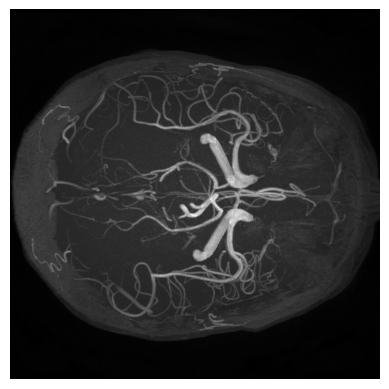

In [5]:
nv.imshow(img, display='orth', index='max');

In [ ]:
repo.assets

In [8]:
img = repo.scans(
    subject_uid='PESA10407076', 
    modality='tof',
    asset_type='dicom', 
    series_description='cs3DI_MC', 
    get_image=True, 
    xnat_config=XnatConnectionConfig(
        server='https://xnat.cnic.es',
        project='PESA_Brain',
        netrc_file='~/.netrc',
    ),
    imread_kwargs={'force_ras': True}
)
print(img)
print(img.shape)
print(img.modality)
print(img.submodality)
print(img.backend)
print(img.axes)
print(img.rescale_type)
print(img.is_4d)
print(img.orientation)
print(img.affine)

[WARNING] Verify is disabled, this will NOT verify the certificate of SSL connections!
[WARNING] Warnings about invalid certificates will be HIDDEN to avoid spam, but this
[WARNING] means that your connection can be potentially unsafe!


Image(shape=(800, 800, 180), dtype=uint16, backend=cupy, axes='XYZ', orientation='ARS', name='nvitk_xnat_scan_l6dv8run', modality='MR', submodality='cs3DI_MC', rescale_type='DV')
(800, 800, 180)
MR
cs3DI_MC
cupy
XYZ
DV
False
ARS
[[ 1.65391737e-03  2.49968231e-01 -7.25145841e-03 -9.84643643e+01]
 [ 2.48388842e-01 -1.23283523e-03  5.66202990e-02 -9.95419807e+01]
 [-2.82886773e-02  3.78965377e-03  4.96730795e-01 -2.96015767e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


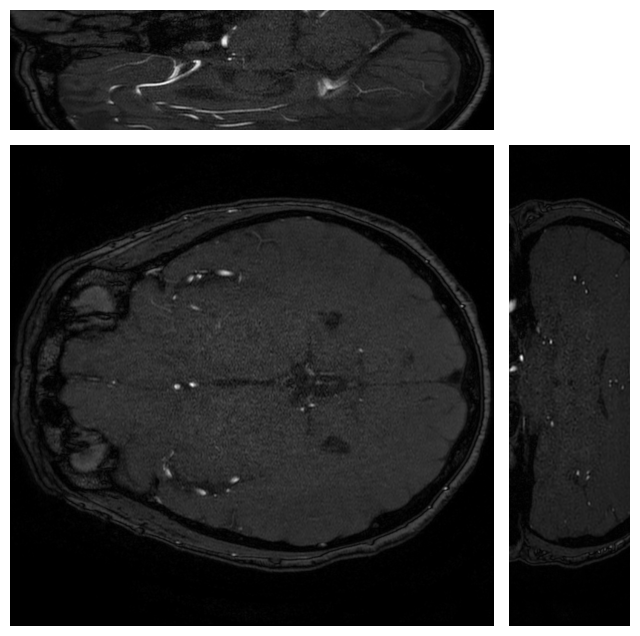

In [5]:
nv.imshow(img, display='orth');

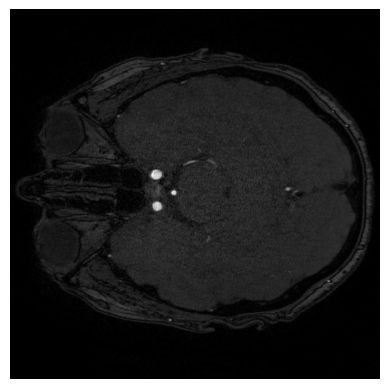

In [11]:
sub = img.copy()
sub.data = img.data.take(indices=50, axis=2)
nv.imshow(sub);

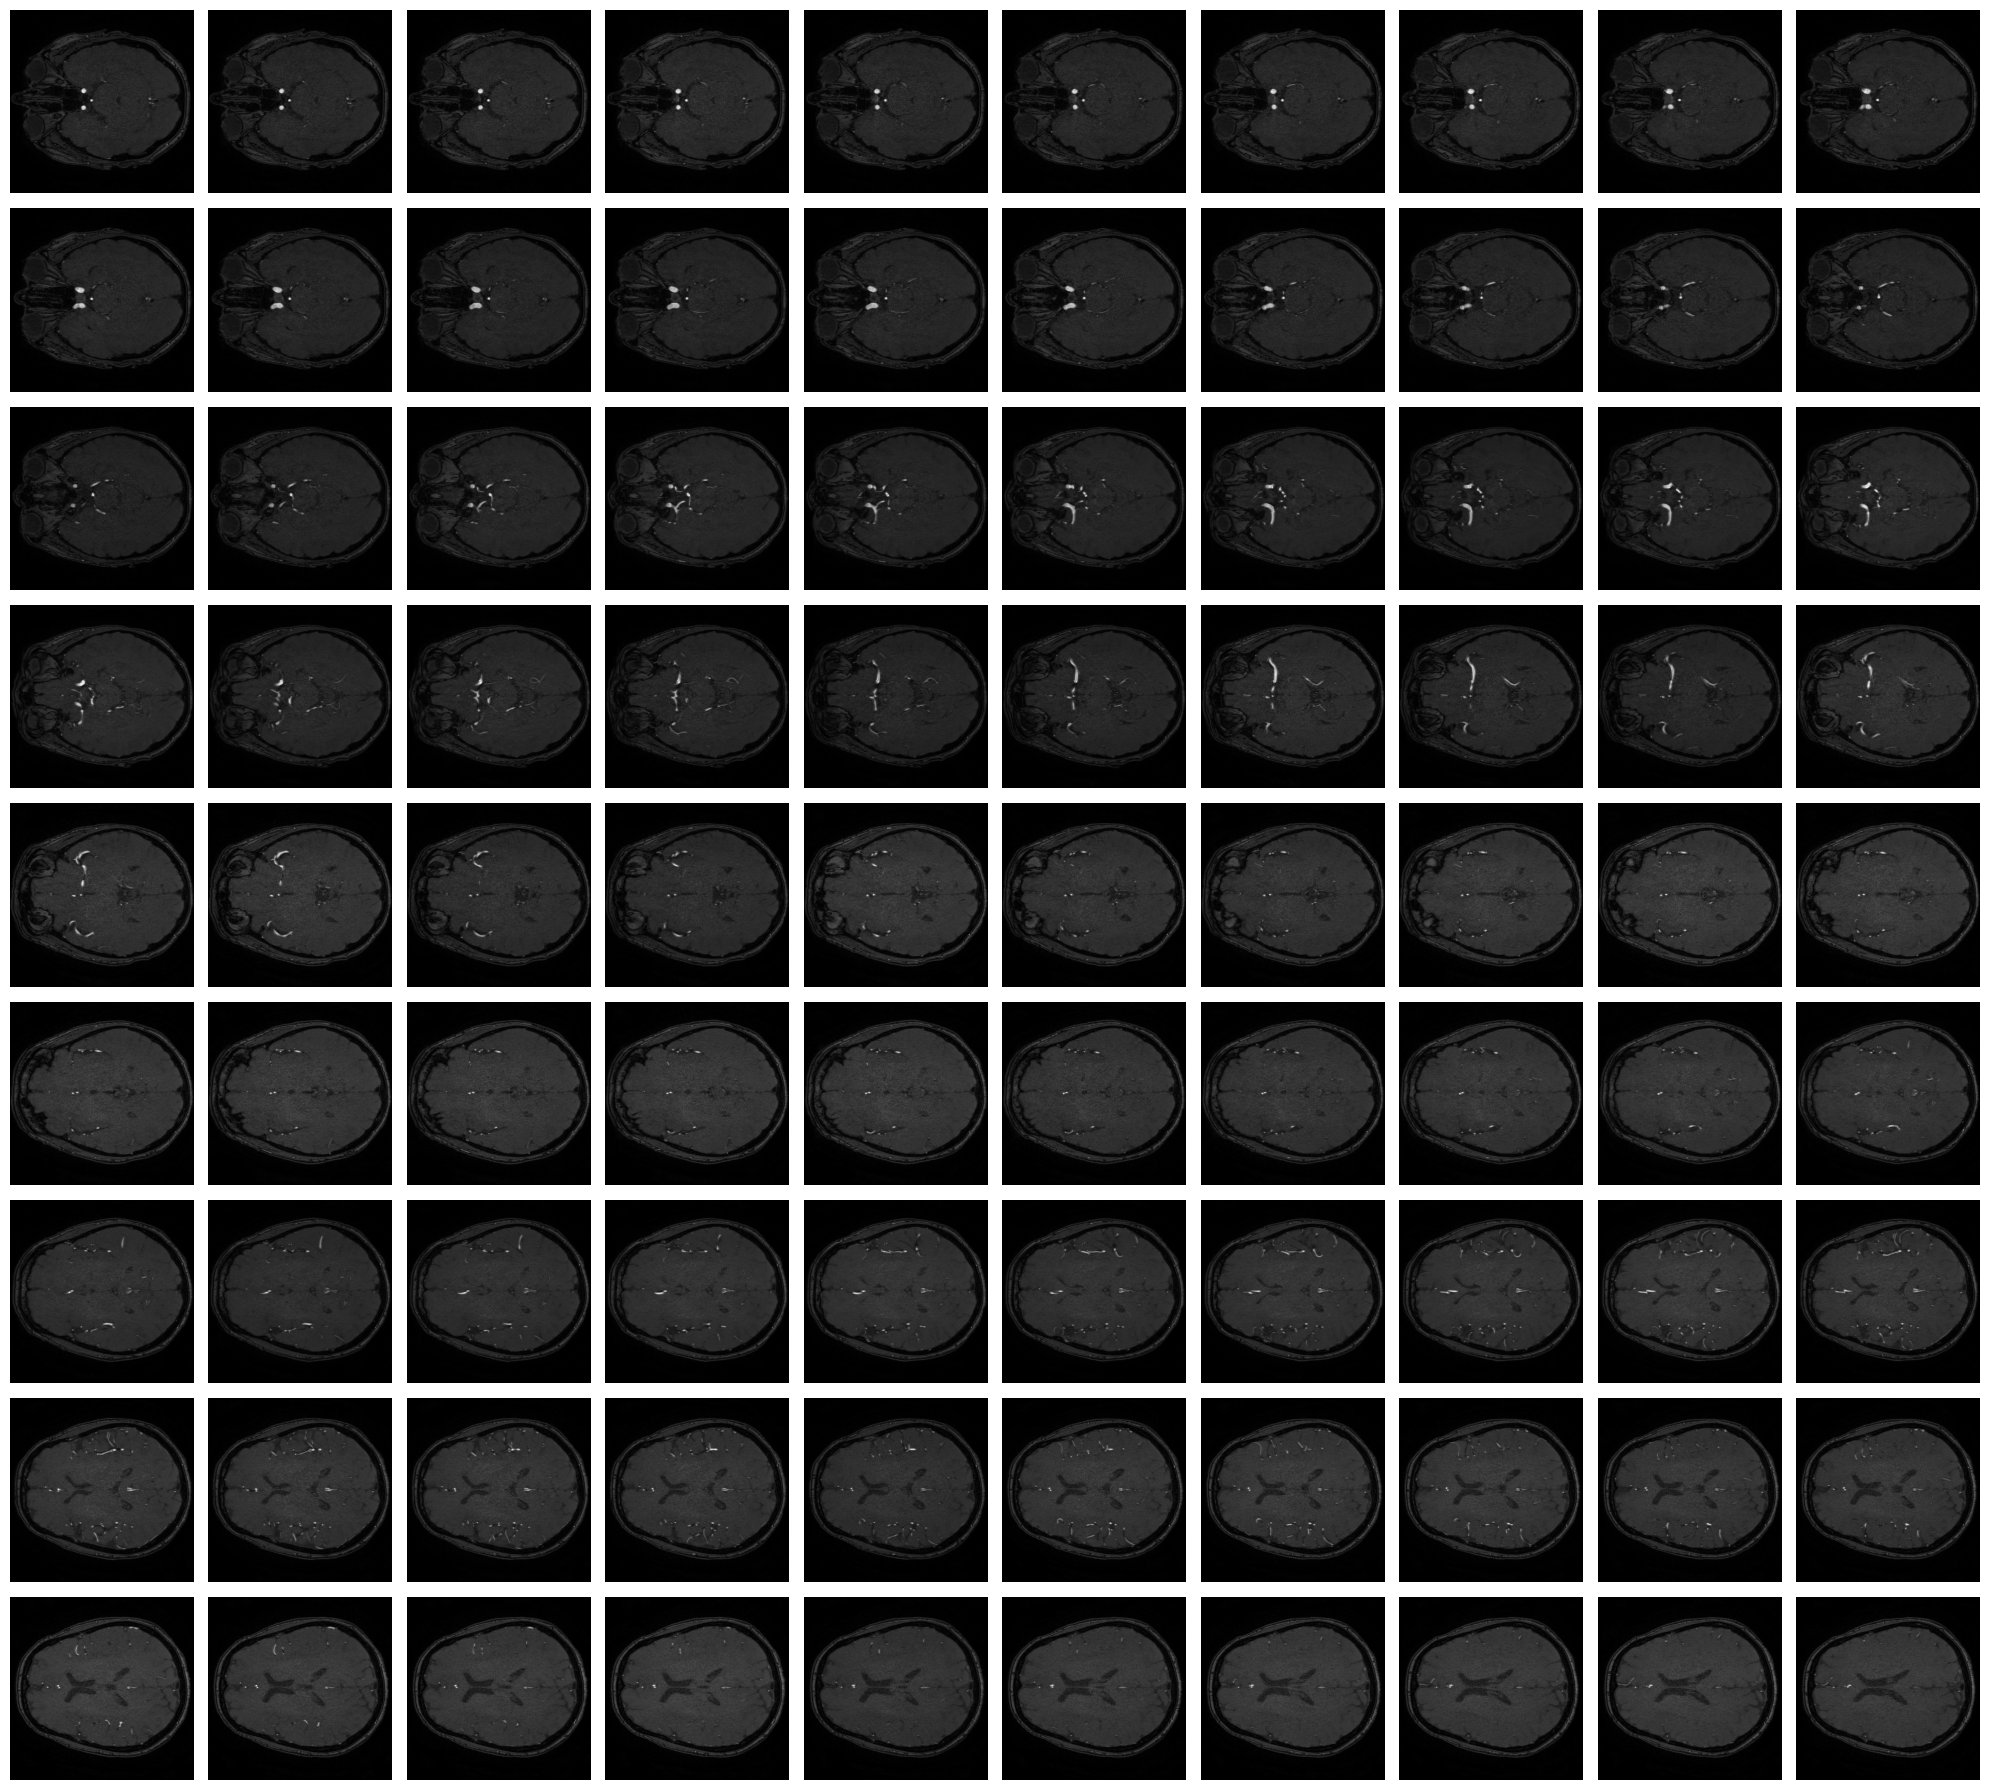

In [8]:
nv.imshow(img, display='mosaic', mosaic_init=45, mosaic_fin=135)

In [6]:
img = nv.imread('/data_local/LabVF/PESA-Brain/DATA/Nifti/PESA10758400/4DFlow/ComplexDifference_4D.nii')
img


Image(shape=(256, 256, 101, 15), dtype=float64, backend=cupy, axes='XYZT', orientation='RAS', name='ComplexDifference_4D', modality='MR', submodality=None, rescale_type='DV')

In [10]:
from IPython.display import HTML
ani = nv.imshow(img, display='animation', index=30)
_html = HTML(ani.to_jshtml())

with open('anim.html', 'w') as f:
    f.write(_html.data)


In [6]:
img = repo.scans(
    subject_uid='PESA10407076', 
    modality='tof',
    asset_type='dicom', 
    series_description='MIP - cs3DI_MC', 
    get_image=True, 
    xnat_config=XnatConnectionConfig(
        server='https://xnat.cnic.es',
        project='PESA_Brain',
        netrc_file='~/.netrc',
    )
)
print(img)


[WARNING] Verify is disabled, this will NOT verify the certificate of SSL connections!
[WARNING] Warnings about invalid certificates will be HIDDEN to avoid spam, but this
[WARNING] means that your connection can be potentially unsafe!


Image(shape=(800, 800, 3), dtype=uint16, backend=cupy, axes='XYZ', orientation='IAL', name='nvitk_xnat_scan_1xnax55n', modality='MR', submodality='MIP - cs3DI_MC', rescale_type='DV')


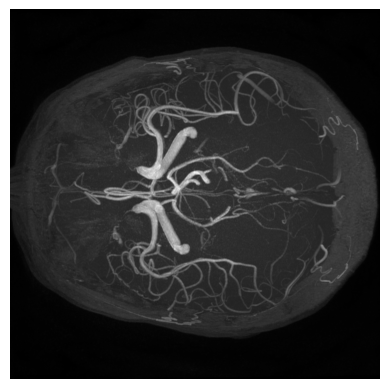

In [10]:
nv.imshow(img, display='standard');

In [4]:
img = repo.scans(
    subject_uid='PESA10407076', 
    modality='qsm',
    asset_type='nifti', 
    get_image=True, 
    xnat_config=XnatConnectionConfig(
        server='https://xnat.cnic.es',
        project='PESA_Brain',
        netrc_file='~/.netrc',
    )
)
if isinstance(img, list): [print(f'{i}\n') for i in img]
else: print(img)

[WARNING] Verify is disabled, this will NOT verify the certificate of SSL connections!
[WARNING] Warnings about invalid certificates will be HIDDEN to avoid spam, but this
[WARNING] means that your connection can be potentially unsafe!


Downloaded NIfTI files to PosixPath('/tmp/nvitk_xnat_scan_k34u0sjf')
Image(shape=(432, 432, 140), dtype=float64, backend=cupy, axes='XYZ', orientation='RAS', name='BMRI395267_QSM_1303_e1.nii', modality=None, submodality=None, rescale_type='DV')

Image(shape=(432, 432, 140), dtype=float64, backend=cupy, axes='XYZ', orientation='RAS', name='BMRI395267_QSM_1303_e1_ph.nii', modality=None, submodality=None, rescale_type='DV')

Image(shape=(432, 432, 140), dtype=float64, backend=cupy, axes='XYZ', orientation='RAS', name='BMRI395267_QSM_1303_e2.nii', modality=None, submodality=None, rescale_type='DV')

Image(shape=(432, 432, 140), dtype=float64, backend=cupy, axes='XYZ', orientation='RAS', name='BMRI395267_QSM_1303_e2_ph.nii', modality=None, submodality=None, rescale_type='DV')

Image(shape=(432, 432, 140), dtype=float64, backend=cupy, axes='XYZ', orientation='RAS', name='BMRI395267_QSM_1303_e3.nii', modality=None, submodality=None, rescale_type='DV')

Image(shape=(432, 432, 140), dtype=float

In [13]:
img = repo.scans(
    subject_uid='PESA10407076', 
    modality='fmri',
    asset_slot='resting_state_mb',
    asset_type='dicom', 
    get_image=True, 
    xnat_config=XnatConnectionConfig(
        server='https://xnat.cnic.es',
        project='PESA_Brain',
        netrc_file='~/.netrc',
    )
)
if isinstance(img, list): [print(f'{i}\n') for i in img]
else: print(img)

[WARNING] Verify is disabled, this will NOT verify the certificate of SSL connections!
[WARNING] Warnings about invalid certificates will be HIDDEN to avoid spam, but this
[WARNING] means that your connection can be potentially unsafe!


Image(shape=(144, 144, 22950), dtype=uint16, backend=cupy, axes='XYZ', orientation='ARS', name='nvitk_xnat_scan_yu5cjtku', modality='MR', submodality='RESTING STATE MB', rescale_type='DV')


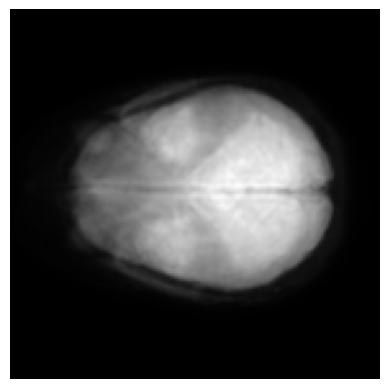

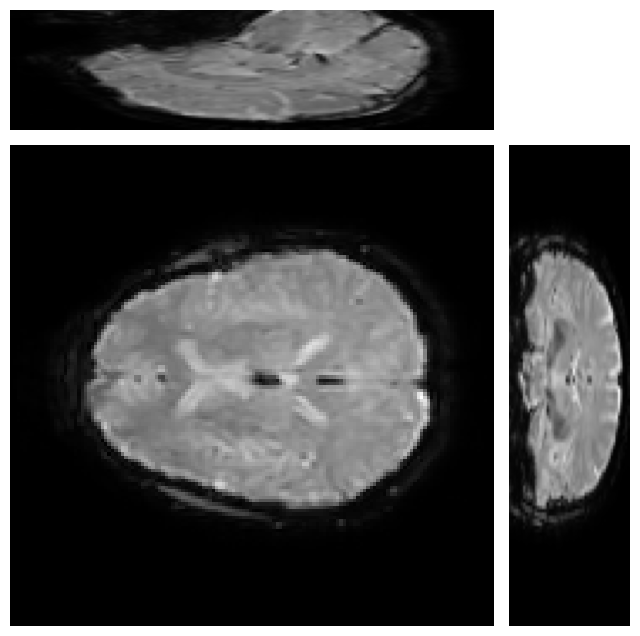

In [21]:
nv.imshow(img, index='avg');
nv.imshow(img, index='mid');


In [5]:
img = repo.scans(
    subject_uid='PESA10407076', 
    modality='qsm',
    asset_type='dicom', 
    get_image=True, 
    xnat_config=XnatConnectionConfig(
        server='https://xnat.cnic.es',
        project='PESA_Brain',
        netrc_file='~/.netrc',
    )
)
if isinstance(img, list): [print(f'{i}\n') for i in img]
else: print(img)

[WARNING] Verify is disabled, this will NOT verify the certificate of SSL connections!
[WARNING] Warnings about invalid certificates will be HIDDEN to avoid spam, but this
[WARNING] means that your connection can be potentially unsafe!


[info]Splitting series into 2 subseries by ImageType[/info]
Image(shape=(432, 432, 840), dtype=uint16, backend=cupy, axes='XYZ', orientation='ARS', name='nvitk_xnat_scan_r379zx2l', modality='MR', submodality='QSM', rescale_type='DV')

Image(shape=(432, 432, 840), dtype=uint16, backend=cupy, axes='XYZ', orientation='ARS', name='nvitk_xnat_scan_r379zx2l', modality='MR', submodality='QSM', rescale_type='DV')



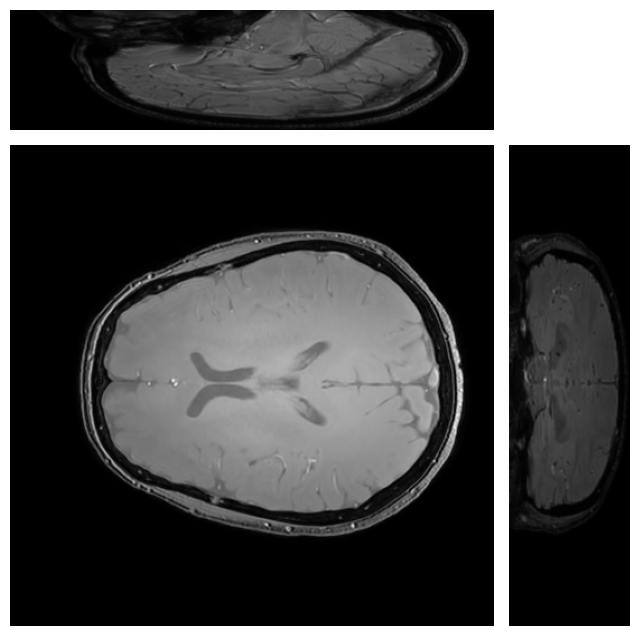

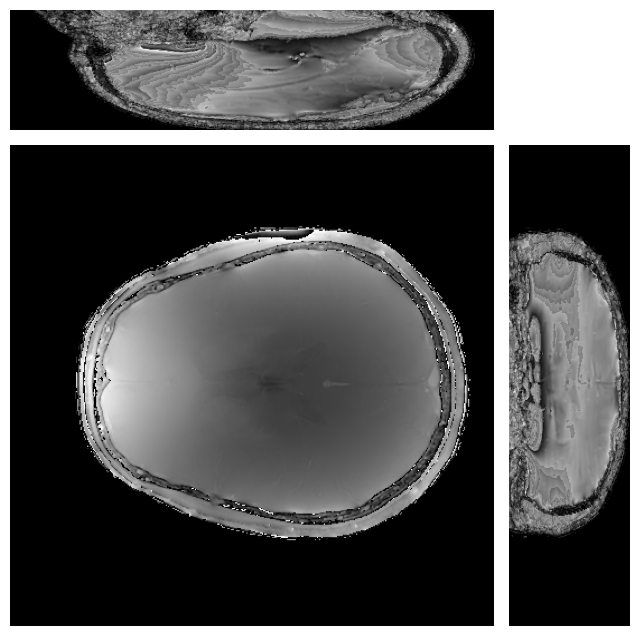

In [ ]:
nv.imshow(img[0], display='orth')
nv.imshow(img[1], display='orth')
## Trabaja perrooooo

In [32]:
img = repo.scans(
    subject_uid='PESA10407076', 
    modality='flair',
    asset_type='dicom', 
    get_image=True, 
    xnat_config=XnatConnectionConfig(
        server='https://xnat.cnic.es',
        project='PESA_Brain',
        netrc_file='~/.netrc',
    )
)
if isinstance(img, list): [print(f'{i}\n') for i in img]
else: print(img)

/home/imarcoss/nvitk/src/nvitk/db/repo.py:280: UserWarning: Error querying table cohort_membership with SQLite index. Falling back to parquet read.
  cm = self._load_table_frame(
[WARNING] Verify is disabled, this will NOT verify the certificate of SSL connections!
[WARNING] Warnings about invalid certificates will be HIDDEN to avoid spam, but this
[WARNING] means that your connection can be potentially unsafe!


Image(shape=(256, 256, 360), dtype=uint16, backend=cupy, axes='XYZ', name='nvitk_xnat_scan_c0nupfkn', modality='MR', submodality='3D_FLAIR', rescale_type='DV')


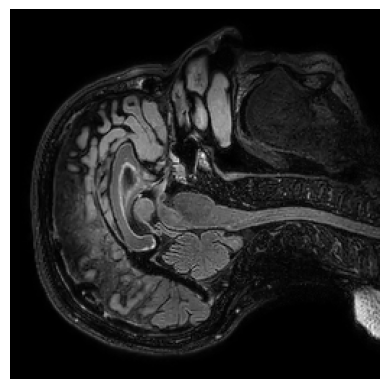

In [33]:
nv.imshow(img, axis=2, cmap='gray')

In [34]:
img = repo.scans(
    subject_uid='PESA10407076', 
    modality='t2',
    asset_type='dicom', 
    get_image=True, 
    xnat_config=XnatConnectionConfig(
        server='https://xnat.cnic.es',
        project='PESA_Brain',
        netrc_file='~/.netrc',
    )
)
if isinstance(img, list): [print(f'{i}\n') for i in img]
else: print(img)

/home/imarcoss/nvitk/src/nvitk/db/repo.py:280: UserWarning: Error querying table cohort_membership with SQLite index. Falling back to parquet read.
  cm = self._load_table_frame(
[WARNING] Verify is disabled, this will NOT verify the certificate of SSL connections!
[WARNING] Warnings about invalid certificates will be HIDDEN to avoid spam, but this
[WARNING] means that your connection can be potentially unsafe!


Image(shape=(512, 512, 380), dtype=uint16, backend=cupy, axes='XYZ', name='nvitk_xnat_scan_ljf92tls', modality='MR', submodality='3D_T2 HR', rescale_type='DV')


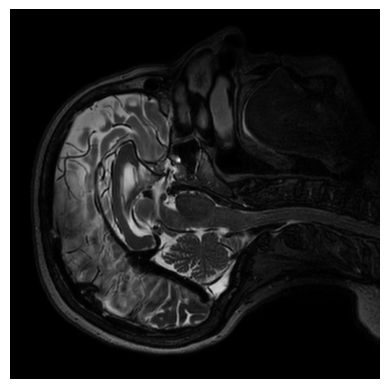

In [35]:
nv.imshow(img, axis=2, cmap='gray')

In [38]:
img = repo.scans(
    subject_uid='PESA10407076', 
    modality='mra',
    asset_slot='carotid_qf',
    asset_type='dicom', 
    get_image=True, 
    xnat_config=XnatConnectionConfig(
        server='https://xnat.cnic.es',
        project='PESA_Brain',
        netrc_file='~/.netrc',
    )
)
if isinstance(img, list): [print(f'{i}\n') for i in img]
else: print(img)

/home/imarcoss/nvitk/src/nvitk/db/repo.py:280: UserWarning: Error querying table cohort_membership with SQLite index. Falling back to parquet read.
  cm = self._load_table_frame(
[WARNING] Verify is disabled, this will NOT verify the certificate of SSL connections!
[WARNING] Warnings about invalid certificates will be HIDDEN to avoid spam, but this
[WARNING] means that your connection can be potentially unsafe!


[info]Splitting series into 3 subseries by ImageType[/info]
Image(shape=(320, 320, 20), dtype=uint16, backend=cupy, axes='XYZ', name='nvitk_xnat_scan_g0b9gced', modality='MR', submodality='carotid_QF', rescale_type='DV')

Image(shape=(320, 320, 20), dtype=uint16, backend=cupy, axes='XYZ', name='nvitk_xnat_scan_g0b9gced', modality='MR', submodality='carotid_QF', rescale_type='DV')

Image(shape=(320, 320, 20), dtype=uint16, backend=cupy, axes='XYZ', name='nvitk_xnat_scan_g0b9gced', modality='MR', submodality='carotid_QF', rescale_type='DV')



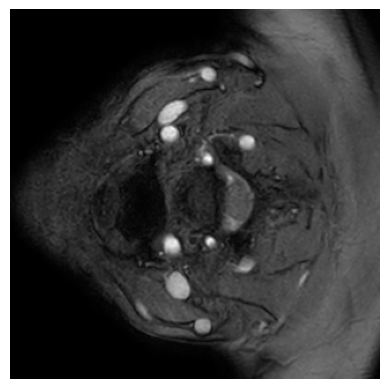

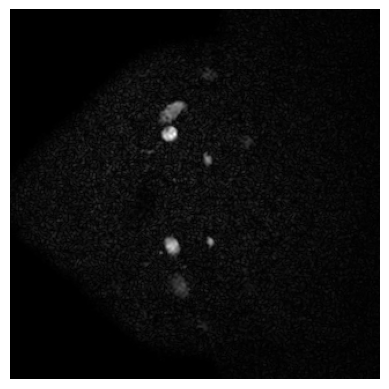

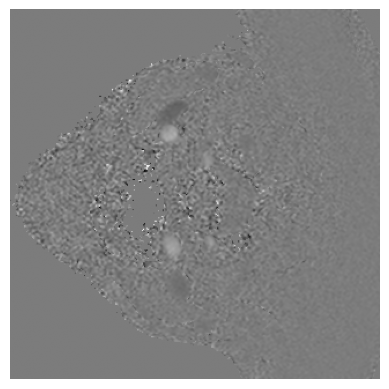

In [39]:
nv.imshow(img[0], axis=2, cmap='gray')
nv.imshow(img[1], axis=2, cmap='gray')
nv.imshow(img[2], axis=2, cmap='gray')